# Data Collection & Quality Assessment (CSC 422)

**Duration:** 45 minutes  
**Format:** Live coding + group exercise  
**Course:** CSC 422 - Machine and Deep Learning

---

## Learning Goals

By the end of class, students will:
- Navigate Kaggle effectively to discover relevant datasets
- Use the HuggingFace datasets library to programmatically load data
- Assess basic dataset quality metrics for ML projects
- Apply dataset validation techniques hands-on
- Select appropriate datasets for their own ML projects

---

## ⏱Timeline

- **0–10 min** — Hook: Dataset Quality + Kaggle Review
- **10–25 min** — HuggingFace Datasets Library Hands-on
- **25–45 min** — Group Exercise: Find, Load & Explore

---

## Setup

We'll need the HuggingFace datasets library plus our standard data science tools.

In [29]:
# Install datasets library if needed
# !pip install datasets

# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# HuggingFace datasets
from datasets import load_dataset

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---

# 0–10 min: Hook - Why Dataset Quality Matters + Kaggle Review

**Goal:** Understand the foundation of successful ML projects and review Kaggle as a data source

## The ML Truth: "Garbage In, Garbage Out"

The most sophisticated algorithm in the world won't save you from bad data.

In [ ]:
print("🎯 THE DATA QUALITY IMPERATIVE:")
print("📊 80% of ML project time = Data collection & cleaning")
print("🤖 20% of ML project time = Model building & tuning")
print("")
print("⚠️  COMMON DATA PROBLEMS:")
print("   • Missing values and inconsistent formats")
print("   • Biased or unrepresentative samples")
print("   • Insufficient data for reliable training")
print("   • Mislabeled or noisy target variables")
print("   • Data leakage (future info in features)")
print("")
print("✅ TODAY'S GOAL: Learn to find and validate quality datasets!")

In [31]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prathamtripathi/drug-classification")

print("Path to dataset files:", path)

100%|██████████| 1.68k/1.68k [00:00<00:00, 1.76MB/s]

Extracting files...
Path to dataset files: /Users/rmoseley/.cache/kagglehub/datasets/prathamtripathi/drug-classification/versions/1


## Kaggle: Your Data Goldmine 🏆

**What is Kaggle?**
- World's largest data science community
- 50,000+ public datasets across all domains
- Competitions, kernels, and discussions
- Real-world, industry-contributed data

**Key Navigation Tips:**
1. **Search by topic**: "healthcare", "finance", "nlp", "computer vision"
2. **Filter by size**: Start with medium datasets (1K-100K rows)
3. **Check usability score**: Look for 8.0+ ratings
4. **Read the description**: Understand data collection methodology
5. **Examine data card**: Check for missing values, data types

**Quality Indicators to Look For:**
- ✅ Clear documentation and data dictionary
- ✅ Reasonable data size (not too small, not too massive)
- ✅ Recent updates and community engagement
- ✅ Proper licensing (usually CC0 or Open Database)
- ✅ Low percentage of missing values
- ✅ Balanced classes (for classification problems)

**Red Flags to Avoid:**
- ❌ No documentation or unclear data sources
- ❌ Extremely imbalanced datasets (99% one class)
- ❌ Too many missing values (>20% generally)
- ❌ Suspicious perfect correlations
- ❌ Data that seems "too good to be true"

---

# 10–25 min: HuggingFace Datasets Library Hands-on

**Goal:** Learn to programmatically load and explore datasets using the HuggingFace datasets library

## What is HuggingFace Datasets?

- **Unified interface** for loading 1000+ datasets
- **Automatic caching** - download once, use forever
- **Memory efficient** - works with datasets larger than RAM
- **Consistent API** - same interface for all datasets
- **Built-in preprocessing** - tokenization, feature extraction

Think of it as "scikit-learn for dataset loading"!

## Exploring Available Datasets

In [32]:
# Since list_datasets() is deprecated, let's explore some popular datasets
# Here are some well-known datasets available on HuggingFace:

popular_datasets = [
    "imdb", "amazon_reviews_multi", "yelp_review_full", "squad",
    "glue", "super_glue", "conll2003", "mnist", "fashion_mnist", 
    "cifar10", "cifar100", "food101", "beans", "common_voice"
]

print(f"Popular datasets examples ({len(popular_datasets)} shown):")
for i, dataset_name in enumerate(popular_datasets[:10]):
    print(f"  {i+1}. {dataset_name}")
    
print(f"\nFor more datasets, visit: https://huggingface.co/datasets")
print(f"💡 TIP: Look for datasets with many downloads and recent activity!")

Popular datasets examples (14 shown):
  1. imdb
  2. amazon_reviews_multi
  3. yelp_review_full
  4. squad
  5. glue
  6. super_glue
  7. conll2003
  8. mnist
  9. fashion_mnist
  10. cifar10

For more datasets, visit: https://huggingface.co/datasets
💡 TIP: Look for datasets with many downloads and recent activity!


In [33]:
# Look for datasets by domain/topic
domains = {
    'text_classification': ['imdb', 'amazon_reviews_multi', 'yelp_review_full'],
    'question_answering': ['squad'],
    'computer_vision': ['cifar10', 'mnist', 'fashion_mnist', 'beans'],
    'audio': ['common_voice'],
    'natural_language': ['glue', 'super_glue', 'conll2003']
}

print("📂 DATASETS BY DOMAIN:")
for domain, datasets in domains.items():
    print(f"\n{domain.upper().replace('_', ' ')}:")
    for dataset in datasets:
        print(f"  • {dataset}")
        
print(f"\n💡 TIP: Visit https://huggingface.co/datasets to search by keywords!")
print(f"🔍 SEARCH STRATEGY: Use filters for task type, language, size, etc.")

📂 DATASETS BY DOMAIN:

TEXT CLASSIFICATION:
  • imdb
  • amazon_reviews_multi
  • yelp_review_full

QUESTION ANSWERING:
  • squad

COMPUTER VISION:
  • cifar10
  • mnist
  • fashion_mnist
  • beans

AUDIO:
  • common_voice

NATURAL LANGUAGE:
  • glue
  • super_glue
  • conll2003

💡 TIP: Visit https://huggingface.co/datasets to search by keywords!
🔍 SEARCH STRATEGY: Use filters for task type, language, size, etc.


## Loading Your First Dataset

Let's start with a classic: the IMDB movie reviews dataset

In [34]:
# Load the IMDB movie reviews dataset
dataset = load_dataset("imdb")
print("✅ Dataset loaded!")
print(f"Dataset object type: {type(dataset)}")
print(f"Available splits: {list(dataset.keys())}")

✅ Dataset loaded!
Dataset object type: <class 'datasets.dataset_dict.DatasetDict'>
Available splits: ['train', 'test', 'unsupervised']


In [35]:
# Get the training split
train_data = dataset['train']
print(f"Training data size: {len(train_data)} examples")
print(f"Features: {train_data.features}")

Training data size: 25000 examples
Features: {'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}


In [36]:
# Look at the first few examples
print("First 3 examples:")
for i in range(20):
    print(f"Example {i+1}: {train_data[i]}")
    print()

First 3 examples:
Example 1: {'text': 'I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nud

## Converting to Pandas for Analysis

HuggingFace datasets play nicely with pandas for familiar data analysis

In [37]:
# Convert to pandas DataFrame
df = train_data.to_pandas()
print(f"DataFrame shape: {df.shape}")
print("\nFirst few rows:")
df.head()

DataFrame shape: (25000, 2)

First few rows:


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


## Quick Dataset Quality Assessment

In [38]:
# Basic info about the dataset
print("📊 DATASET QUALITY REPORT:")
print(f"   • Size: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"   • Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"   • Missing values: {df.isnull().sum().sum()} total")
print(f"   • Duplicate rows: {df.duplicated().sum()}")

# Data types
print("\n📈 DATA TYPES:")
print(df.dtypes.value_counts())

📊 DATASET QUALITY REPORT:
   • Size: 25000 rows, 2 columns
   • Memory usage: 33.03 MB
   • Missing values: 0 total
   • Duplicate rows: 96

📈 DATA TYPES:
object    1
int64     1
Name: count, dtype: int64


In [39]:
# Missing value analysis
print("🔍 MISSING VALUES BY COLUMN:")
missing_data = df.isnull().sum()
if missing_data.sum() > 0:
    missing_percent = (missing_data / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Count': missing_data,
        'Percentage': missing_percent
    })
    print(missing_df[missing_df['Missing Count'] > 0])
else:
    print("✅ No missing values found!")

🔍 MISSING VALUES BY COLUMN:
✅ No missing values found!


🎯 TARGET VARIABLE ANALYSIS:
   • Unique values: 2
   • Value range: 0 to 1
   • Class meanings: 0=negative, 1=positive

   • Distribution:
label
0    12500
1    12500
Name: count, dtype: int64


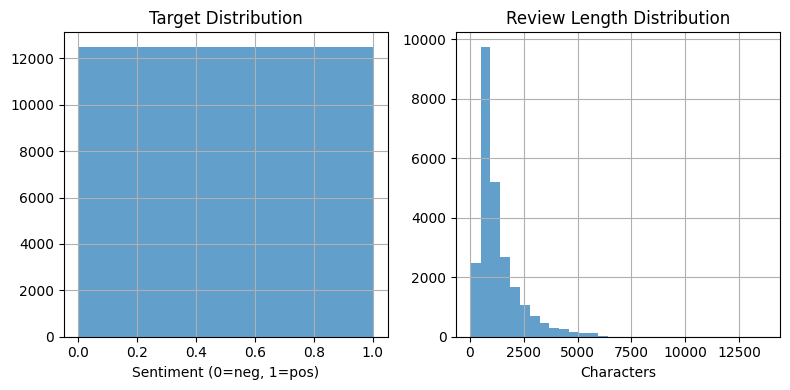

In [40]:
# Target variable analysis (assuming 'label' is the target for IMDB)
if 'label' in df.columns:
    print("🎯 TARGET VARIABLE ANALYSIS:")
    print(f"   • Unique values: {df['label'].nunique()}")
    print(f"   • Value range: {df['label'].min()} to {df['label'].max()}")
    print("   • Class meanings: 0=negative, 1=positive")
    print("\n   • Distribution:")
    print(df['label'].value_counts().sort_index())
    
    # Quick visualization
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    df['label'].hist(bins=2, alpha=0.7)
    plt.title('Target Distribution')
    plt.xlabel('Sentiment (0=neg, 1=pos)')
    
    plt.subplot(1, 2, 2)
    # Show text length distribution
    df['text_length'] = df['text'].str.len()
    df['text_length'].hist(bins=30, alpha=0.7)
    plt.title('Review Length Distribution')
    plt.xlabel('Characters')
    plt.tight_layout()
    plt.show()
elif 'quality' in df.columns:
    print("🎯 TARGET VARIABLE ANALYSIS:")
    print(f"   • Unique values: {df['quality'].nunique()}")
    print(f"   • Value range: {df['quality'].min()} to {df['quality'].max()}")
    print("\n   • Distribution:")
    print(df['quality'].value_counts().sort_index())
    
    # Quick visualization
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    df['quality'].hist(bins=10, alpha=0.7)
    plt.title('Target Distribution')
    plt.xlabel('Quality Score')
    
    plt.subplot(1, 2, 2)
    df.boxplot(column='quality')
    plt.title('Target Box Plot')
    plt.tight_layout()
    plt.show()
else:
    print("🎯 TARGET VARIABLE ANALYSIS:")
    print("   No obvious target column found. Common target names:")
    print("   • 'label', 'target', 'class', 'y'")
    print("   Check column names:", list(df.columns))

## Dataset Loading Template

Here's a reusable template for loading and quickly assessing any dataset:

In [ ]:
def quick_dataset_assessment(dataset_name, split='train'):
    """
    Load a HuggingFace dataset and perform quick quality assessment
    """
    print(f"📦 Loading dataset: {dataset_name}")
    
    try:
        # Load dataset
        dataset = load_dataset(dataset_name)
        data = dataset[split]
        df = data.to_pandas()
        
        print(f"✅ Dataset loaded successfully!")
        print(f"   • Shape: {df.shape}")
        print(f"   • Columns: {list(df.columns)}")
        print(f"   • Missing values: {df.isnull().sum().sum()}")
        print(f"   • Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
        
        return df
        
    except Exception as e:
        print(f"❌ Error loading dataset: {e}")
        return None

# Test the function
print("Testing our assessment function:")
test_df = quick_dataset_assessment("imdb")

---

# 25–45 min: Group Exercise - Find, Load & Explore

**Goal:** Apply your new skills in small groups to discover and assess datasets

## 🔬 Your Mission: Dataset Discovery & Assessment

**Time:** 20 minutes  
**Format:** Groups of 2-3 students  
**Deliverable:** Brief presentation of your findings  

### Step 1: Choose Your Dataset (5 minutes)

**Option A: Pick from our curated list (verified working datasets)**
- `"imdb"` - Movie reviews (text classification)
- `"mnist"` - Handwritten digits (image classification)
- `"fashion_mnist"` - Clothing images (image classification)
- `"beans"` - Bean leaf disease (image classification)
- `"squad"` - Reading comprehension (question answering)
- `"yelp_review_full"` - Restaurant reviews (text classification)

**Option B: Find your own**
- Browse the HuggingFace Hub: https://huggingface.co/datasets
- Search for datasets in your domain of interest
- Pick something that looks interesting!
- **Tip:** Look for datasets with high download counts

### Step 2: Load & Explore (10 minutes)

Use the cells below to:
1. Load your chosen dataset
2. Explore its structure and content
3. Assess its quality using our techniques
4. Identify potential ML applications

### Step 3: Prepare Your Report (3 minutes)

Be ready to share:
- **Dataset name and domain**
- **Size and structure** (rows, columns, data types)
- **Quality assessment** (missing values, balance, etc.)
- **Potential ML problem** (classification, regression, clustering)
- **One interesting finding** from your exploration

### Step 4: Group Presentations (2 minutes each)

Quick 1-2 minute presentations from each group!

## 🎯 Your Group's Workspace

**Group Members:** _[Write your names here]_  
**Dataset Choice:** _[Write dataset name here]_  
**Domain:** _[e.g., healthcare, NLP, computer vision, etc.]_

In [ ]:
# Step 1: Load your chosen dataset
# Replace "your_dataset_name" with your actual choice

dataset_name = "_____________"  # Fill in your dataset name
print(f"Loading dataset: {dataset_name}")

# YOUR CODE HERE:
# dataset = load_dataset(dataset_name)
# data = dataset['train']  # or appropriate split
# df = data.to_pandas()

In [ ]:
# Step 2: Basic exploration
# YOUR CODE HERE:
# Explore shape, columns, data types, first few rows

print("📊 BASIC INFO:")
# print(f"Shape: {df.shape}")
# print(f"Columns: {list(df.columns)}")
# print(f"Data types: {df.dtypes.value_counts()}")

# Show first few examples
# df.head()

In [ ]:
# Step 3: Quality assessment
# YOUR CODE HERE:
# Check for missing values, duplicates, target distribution

print("🔍 QUALITY ASSESSMENT:")
# missing_values = df.isnull().sum()
# print(f"Missing values: {missing_values.sum()}")
# print(f"Duplicate rows: {df.duplicated().sum()}")

# If you have a target column, analyze its distribution
# target_column = "_____"  # Fill in if applicable
# df[target_column].value_counts()

In [ ]:
# Step 4: Create a visualization (optional but recommended)
# YOUR CODE HERE:
# Create a plot that shows something interesting about your data

# Examples:
# - Histogram of target variable
# - Correlation heatmap
# - Sample images (if image dataset)
# - Word cloud (if text dataset)

plt.figure(figsize=(10, 6))
# Your visualization code here
plt.title("Your Dataset Visualization")
plt.show()

## 📝 Your Group's Findings

**Complete this summary for your presentation:**

**Dataset:** _[Name and brief description]_

**Size & Structure:**
- Rows: _[number]_
- Columns: _[number]_
- Data types: _[mix of numeric/text/categorical]_

**Quality Assessment:**
- Missing values: _[percentage or count]_
- Data quality: _[Good/Fair/Poor and why]_
- Balance: _[For classification: balanced/imbalanced]_

**ML Application:**
- Problem type: _[Classification/Regression/Other]_
- Potential use case: _[What could you predict/classify?]_

**Most Interesting Finding:**
_[What surprised you or seemed most noteworthy?]_

**Recommendation:**
- Would you use this dataset for a project? _[Yes/No and why]_

---

## Wrap-Up: What You've Accomplished

In just 45 minutes, you've learned to:

✅ **Navigate dataset resources** - Kaggle and HuggingFace Hub  
✅ **Load datasets programmatically** - Using the datasets library  
✅ **Assess data quality** - Missing values, distribution, balance  
✅ **Apply skills immediately** - Hands-on group exploration  
✅ **Share findings** - Communicate dataset insights effectively  

### Next Steps for Your Projects:

1. **Explore more datasets** - Browse HuggingFace Hub and Kaggle
2. **Practice quality assessment** - Use our template on different data
3. **Consider ethical implications** - Data bias, privacy, licensing
4. **Document your choices** - Keep notes on why you selected specific datasets

### Useful Resources:

- **HuggingFace Datasets Hub:** https://huggingface.co/datasets
- **Kaggle Datasets:** https://www.kaggle.com/datasets
- **Dataset Documentation:** Always read the dataset cards!
- **Community Discussions:** Check comments and kernels for insights

**Remember:** The quality of your data will largely determine the success of your ML project. Take time to choose and validate your datasets carefully!